# 04 — Regime Detection (HMM + GMM)

**Purpose:** Identify distinct market regimes (Bull, Transition, Bear) using unsupervised
learning on market-level signals.

**Architecture:**
- **Hidden Markov Model (HMM)**: Captures regime transitions with Gaussian emissions.
  `State 0` = Low-vol/Bull, `State 1` = Transition, `State 2` = High-vol/Bear
- **Gaussian Mixture Model (GMM)**: Cross-checks HMM with static clustering on return/vol features
- **VIX Proxy**: Computed from cross-sectional average of stock volatilities

**Regime state feeds into:**
- Alpha models as a conditioning feature
- Meta-model as a market context signal
- HRP portfolio for regime-conditional position sizing

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
import json
import pickle

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from hmmlearn import hmm
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.stats import ks_2samp

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────────
WD = Path('.')

# ── Parameters ────────────────────────────────────────────────────────────────
N_REGIMES    = 3     # number of market regimes
HMM_ITER     = 200   # HMM EM iterations
VOL_WINDOW   = 21    # rolling volatility window for VIX proxy
MOM_WINDOW   = 21    # rolling return window for market momentum

# Regime labels (assigned post-hoc by volatility level)
REGIME_NAMES = {0: 'Bull', 1: 'Transition', 2: 'Bear'}
REGIME_COLORS = {'Bull': '#4CAF50', 'Transition': '#FF9800', 'Bear': '#f44336'}

print('✓ Imports loaded')

✓ Imports loaded


## 1 — Build Market-Level Signals (VIX Proxy + Market Return)

In [2]:
panel = pd.read_parquet(WD / 'features_panel.parquet')
panel['date'] = pd.to_datetime(panel['date'])

# ── Compute daily market-level signals ────────────────────────────────────────
# Market return = equal-weighted average log return across all tickers
mkt_daily = panel.groupby('date').agg(
    mkt_ret    = ('log_ret', 'mean'),
    mkt_vol    = ('log_ret', 'std'),
    n_stocks   = ('ticker', 'count')
).reset_index()
mkt_daily = mkt_daily.sort_values('date').reset_index(drop=True)

# Rolling signals for the HMM features
mkt_daily['rolling_vol_21']   = mkt_daily['mkt_ret'].rolling(VOL_WINDOW, min_periods=10).std() * np.sqrt(252)
mkt_daily['rolling_vol_63']   = mkt_daily['mkt_ret'].rolling(63, min_periods=30).std() * np.sqrt(252)
mkt_daily['rolling_ret_21']   = mkt_daily['mkt_ret'].rolling(MOM_WINDOW, min_periods=10).mean() * 252
mkt_daily['rolling_ret_63']   = mkt_daily['mkt_ret'].rolling(63, min_periods=30).mean() * 252
mkt_daily['vol_ratio']        = mkt_daily['rolling_vol_21'] / mkt_daily['rolling_vol_63'].replace(0, np.nan)
mkt_daily['drawdown']         = (
    (1 + mkt_daily['mkt_ret']).cumprod() /
    (1 + mkt_daily['mkt_ret']).cumprod().cummax() - 1
)

# Cross-sectional vol dispersion (high = stressed market)
mkt_daily['xs_vol_dispersion'] = (
    panel.groupby('date')['log_ret'].std()
         .reindex(mkt_daily.set_index('date').index).values
)

mkt_daily = mkt_daily.dropna()
print(f'Market signal series: {len(mkt_daily)} trading days')
mkt_daily.tail()

Market signal series: 3117 trading days


,date,mkt_ret,mkt_vol,n_stocks,rolling_vol_21,rolling_vol_63,rolling_ret_21,rolling_ret_63,vol_ratio,drawdown,xs_vol_dispersion
3141,2022-06-28,-0.015178,0.017979,499,0.308640,0.272385,-0.891727,-0.624103,1.133103,-0.190292,0.017979
3142,2022-06-29,-0.006174,0.019214,499,0.293162,0.269874,-1.242112,-0.712738,1.086290,-0.195291,0.019214
3143,2022-06-30,-0.007068,0.015020,499,0.292863,0.269844,-1.216536,-0.710926,1.085307,-0.200978,0.015020
3144,2022-07-01,0.012307,0.016789,499,0.297783,0.270496,-0.937679,-0.604650,1.100876,-0.191145,0.016789
3145,2022-07-05,-0.002927,0.024013,499,0.286837,0.270216,-1.192957,-0.631067,1.061512,-0.193513,0.024013


## 2 — Hidden Markov Model (Primary Regime Detector)

In [3]:
# ── HMM Features ─────────────────────────────────────────────────────────────
# We use a multi-variate Gaussian HMM with the following observations:
#   1. 21-day rolling market volatility (annualized)
#   2. 21-day rolling market return (annualized)
#   3. Volatility ratio (short/long)
#   4. Cross-sectional volatility dispersion
#   5. Drawdown from peak

HMM_FEAT_COLS = [
    'rolling_vol_21',
    'rolling_ret_21',
    'vol_ratio',
    'xs_vol_dispersion',
    'drawdown'
]

hmm_data = mkt_daily.dropna(subset=HMM_FEAT_COLS)[HMM_FEAT_COLS].values
hmm_dates = mkt_daily.dropna(subset=HMM_FEAT_COLS)['date'].values

# Standardize for HMM
hmm_scaler = StandardScaler()
hmm_data_s = hmm_scaler.fit_transform(hmm_data)

# ── Train HMM with multiple restarts ─────────────────────────────────────────
# Multiple restarts needed because HMM EM can get stuck in local optima

best_hmm  = None
best_score = -np.inf

for trial in range(10):  # 10 random restarts
    np.random.seed(trial * 7 + 42)
    model = hmm.GaussianHMM(
        n_components=N_REGIMES,
        covariance_type='full',
        n_iter=HMM_ITER,
        random_state=trial * 7 + 42,
        tol=1e-4
    )
    try:
        model.fit(hmm_data_s)
        score = model.score(hmm_data_s)
        if score > best_score:
            best_score = score
            best_hmm   = model
    except Exception:
        continue

print(f'Best HMM log-likelihood: {best_score:.2f}')
print(f'Converged: {best_hmm.monitor_.converged}')

# Predict hidden states
hmm_states_raw = best_hmm.predict(hmm_data_s)

  File "C:\Users\amart\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


Best HMM log-likelihood: -10536.52
Converged: True


In [4]:
# ── Align HMM states to meaningful names ────────────────────────────────────── 
# State 0 = lowest vol  = Bull
# State 1 = medium vol  = Transition
# State 2 = highest vol = Bear

# Compute mean volatility per state
state_vols = {}
for state in range(N_REGIMES):
    mask = hmm_states_raw == state
    state_vols[state] = hmm_data[mask, 0].mean()  # first feature = rolling_vol_21

# Sort states by volatility → map to {Bull, Transition, Bear}
sorted_states = sorted(state_vols.items(), key=lambda x: x[1])
raw_to_named  = {
    sorted_states[0][0]: 0,  # Bull
    sorted_states[1][0]: 1,  # Transition
    sorted_states[2][0]: 2,  # Bear
}
hmm_states = np.array([raw_to_named[s] for s in hmm_states_raw])

# Build regime DataFrame
regime_df = pd.DataFrame({'date': hmm_dates, 'regime': hmm_states})

# Add state probabilities (posterior)
state_proba = best_hmm.predict_proba(hmm_data_s)
# Reorder columns by vol sorting
reorder = [sorted_states[i][0] for i in range(N_REGIMES)]
state_proba_reordered = state_proba[:, reorder]
for i, name in enumerate(['p_bull', 'p_transition', 'p_bear']):
    regime_df[name] = state_proba_reordered[:, i]

# State statistics
print('── HMM Regime Statistics ──')
for regime, name in REGIME_NAMES.items():
    mask = hmm_states == regime
    n = mask.sum()
    vol = hmm_data[mask[:len(hmm_data)], 0].mean() if mask.sum() > 0 else 0
    ret = hmm_data[mask[:len(hmm_data)], 1].mean() if mask.sum() > 0 else 0
    print(f'  {name:12s}: {n:5d} days ({n/len(hmm_states):.1%})  '
          f'avg_vol={vol:.3f}  avg_ret={ret:.3f}')

── HMM Regime Statistics ──
  Bull        :  1272 days (40.8%)  avg_vol=0.093  avg_ret=0.334
  Transition  :  1216 days (39.0%)  avg_vol=0.149  avg_ret=0.051
  Bear        :   629 days (20.2%)  avg_vol=0.296  avg_ret=-0.111


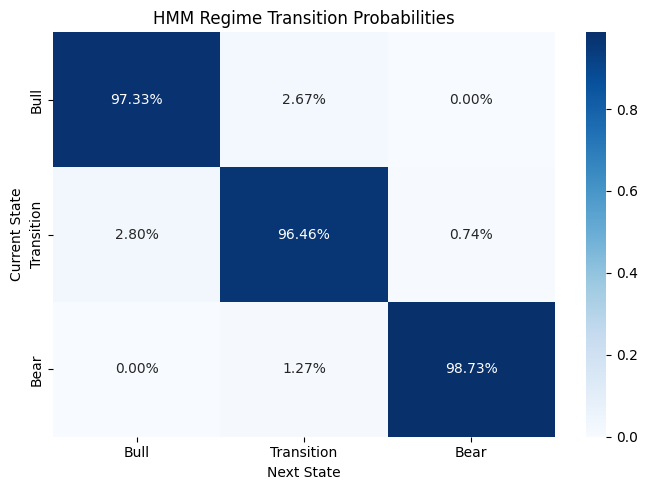

In [5]:
# ── Transition Matrix ──────────────────────────────────────────────────────────
# How likely is each state transition?
trans_counts = np.zeros((N_REGIMES, N_REGIMES), dtype=int)
for i in range(len(hmm_states) - 1):
    trans_counts[hmm_states[i], hmm_states[i + 1]] += 1
trans_proba = trans_counts / trans_counts.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 5))
names = [REGIME_NAMES[i] for i in range(N_REGIMES)]
sns.heatmap(
    trans_proba, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=names, yticklabels=names, ax=ax
)
ax.set_title('HMM Regime Transition Probabilities')
ax.set_xlabel('Next State')
ax.set_ylabel('Current State')
plt.tight_layout()
plt.savefig(WD / 'regime_transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 — GMM Cross-Validation of Regimes

Optimal n_components (BIC): 6


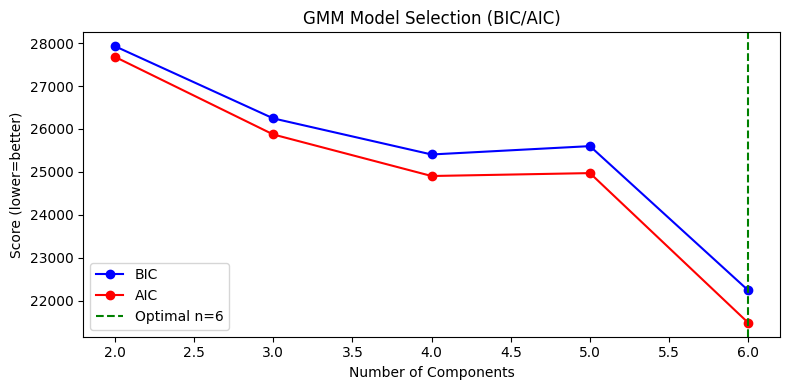

HMM vs GMM agreement: 57.8%


In [6]:
# ── Gaussian Mixture Model ─────────────────────────────────────────────────────
# GMM does NOT model sequential dependencies, just static distribution clusters.
# We compare HMM and GMM to validate regime identification.

# Select optimal n_components using BIC
bic_scores = []
aic_scores = []
n_range = range(2, 7)

for n in n_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full',
                           random_state=42, n_init=10)
    gmm.fit(hmm_data_s)
    bic_scores.append(gmm.bic(hmm_data_s))
    aic_scores.append(gmm.aic(hmm_data_s))

best_n_bic = n_range[np.argmin(bic_scores)]
print(f'Optimal n_components (BIC): {best_n_bic}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_range, bic_scores, 'b-o', label='BIC')
ax.plot(n_range, aic_scores, 'r-o', label='AIC')
ax.axvline(best_n_bic, color='green', linestyle='--', label=f'Optimal n={best_n_bic}')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Score (lower=better)')
ax.set_title('GMM Model Selection (BIC/AIC)')
ax.legend()
plt.tight_layout()
plt.savefig(WD / 'gmm_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# Train final GMM with N_REGIMES=3 (for comparability with HMM)
gmm_final = GaussianMixture(n_components=N_REGIMES, covariance_type='full',
                              random_state=42, n_init=20)
gmm_final.fit(hmm_data_s)
gmm_states_raw = gmm_final.predict(hmm_data_s)

# Align GMM states by volatility
gmm_state_vols = {}
for state in range(N_REGIMES):
    mask = gmm_states_raw == state
    gmm_state_vols[state] = hmm_data[mask, 0].mean() if mask.sum() > 0 else 0
sorted_gmm = sorted(gmm_state_vols.items(), key=lambda x: x[1])
gmm_raw_to_named = {sorted_gmm[i][0]: i for i in range(N_REGIMES)}
gmm_states = np.array([gmm_raw_to_named[s] for s in gmm_states_raw])

# Compare HMM vs GMM agreement
agreement = (hmm_states == gmm_states).mean()
print(f'HMM vs GMM agreement: {agreement:.1%}')

## 4 — Regime Visualization & Validation

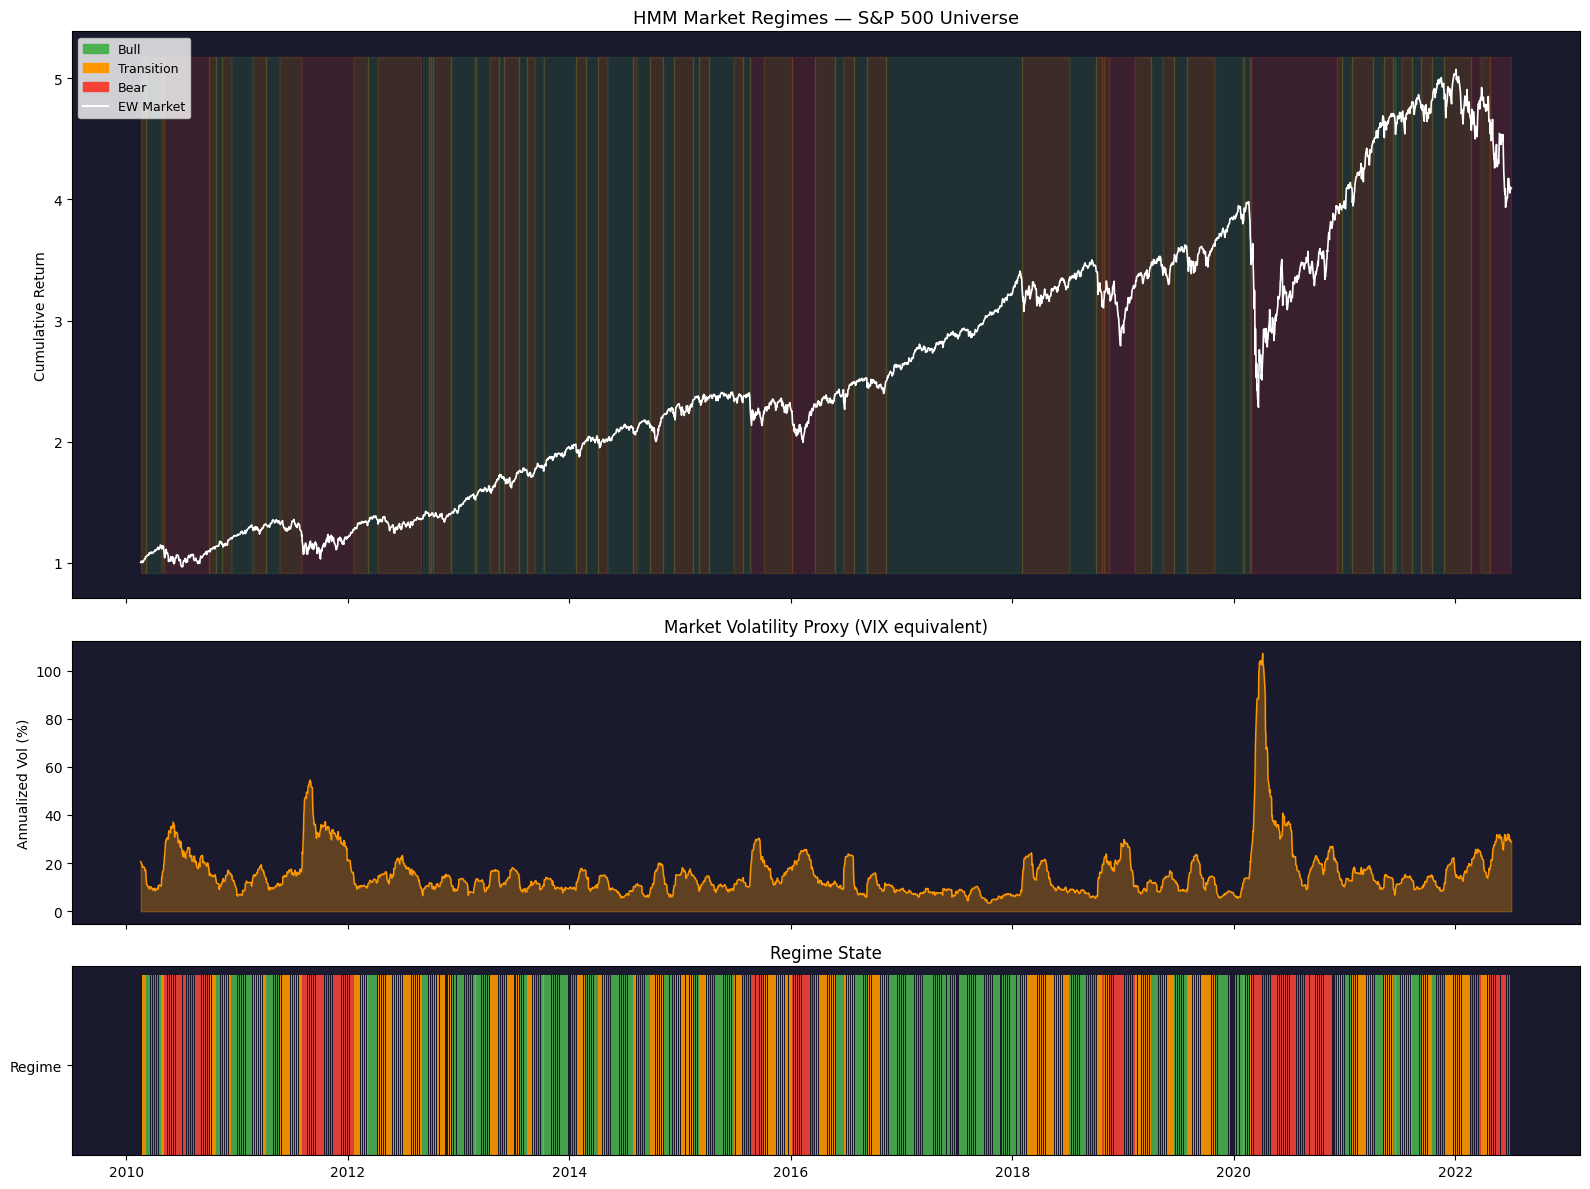

In [7]:
# ── Main Regime Plot ──────────────────────────────────────────────────────────
# Show market cumulative return overlaid with regime shading

mkt_full = mkt_daily.merge(regime_df, on='date', how='left')
mkt_full['regime'] = mkt_full['regime'].fillna(method='ffill').fillna(0).astype(int)

mkt_full['cum_ret'] = (1 + mkt_full['mkt_ret']).cumprod()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1.5, 1]})

# Panel 1: Cumulative return + regime shading
ax = axes[0]
ax.plot(mkt_full['date'], mkt_full['cum_ret'], color='white', linewidth=1.2, label='Market (EW)')

regime_colors_list = [REGIME_COLORS[REGIME_NAMES[r]] for r in mkt_full['regime']]
for regime_id, name in REGIME_NAMES.items():
    mask = mkt_full['regime'] == regime_id
    ymin, ymax = mkt_full['cum_ret'].min() * 0.95, mkt_full['cum_ret'].max() * 1.02
    ax.fill_between(
        mkt_full['date'],
        ymin, ymax,
        where=mask,
        alpha=0.15,
        color=REGIME_COLORS[name]
    )

patches = [mpatches.Patch(color=v, label=k) for k, v in REGIME_COLORS.items()]
ax.legend(handles=patches + [plt.Line2D([], [], color='white', label='EW Market')],
          loc='upper left', fontsize=9)
ax.set_ylabel('Cumulative Return')
ax.set_title('HMM Market Regimes — S&P 500 Universe', fontsize=13)
ax.set_facecolor('#1a1a2e')

# Panel 2: VIX Proxy (rolling vol)
ax = axes[1]
ax.plot(mkt_full['date'], mkt_full['rolling_vol_21'] * 100, color='#FF9800', linewidth=1.0)
ax.fill_between(mkt_full['date'], 0, mkt_full['rolling_vol_21'] * 100, alpha=0.3, color='#FF9800')
ax.set_ylabel('Annualized Vol (%)')
ax.set_title('Market Volatility Proxy (VIX equivalent)')
ax.set_facecolor('#1a1a2e')

# Panel 3: Regime state bar
ax = axes[2]
regime_numeric = mkt_full['regime'].values
colors_bar = [REGIME_COLORS[REGIME_NAMES[r]] for r in regime_numeric]
ax.bar(mkt_full['date'], np.ones(len(mkt_full)), color=colors_bar, width=1, alpha=0.9)
ax.set_yticks([0.5])
ax.set_yticklabels(['Regime'])
ax.set_title('Regime State')
ax.set_facecolor('#1a1a2e')

for ax in axes:
    ax.tick_params(colors='black')

plt.tight_layout()
plt.savefig(WD / 'regime_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

────── Returns by Regime ──────
                mean       std  count  annualized_ret  annualized_vol    sharpe
Bull        0.001078  0.005609   1272       27.169385        8.904767  3.051106
Transition  0.000067  0.009898   1216        1.678020       15.712878  0.106793
Bear        0.000281  0.021026    629        7.092769       33.377020  0.212505

── Kolmogorov-Smirnov Tests ──
  Bull vs Transition    : KS=0.1476  p=0.000000  ✓ significant
  Bull vs Bear          : KS=0.2268  p=0.000000  ✓ significant
  Transition vs Bear    : KS=0.1525  p=0.000000  ✓ significant


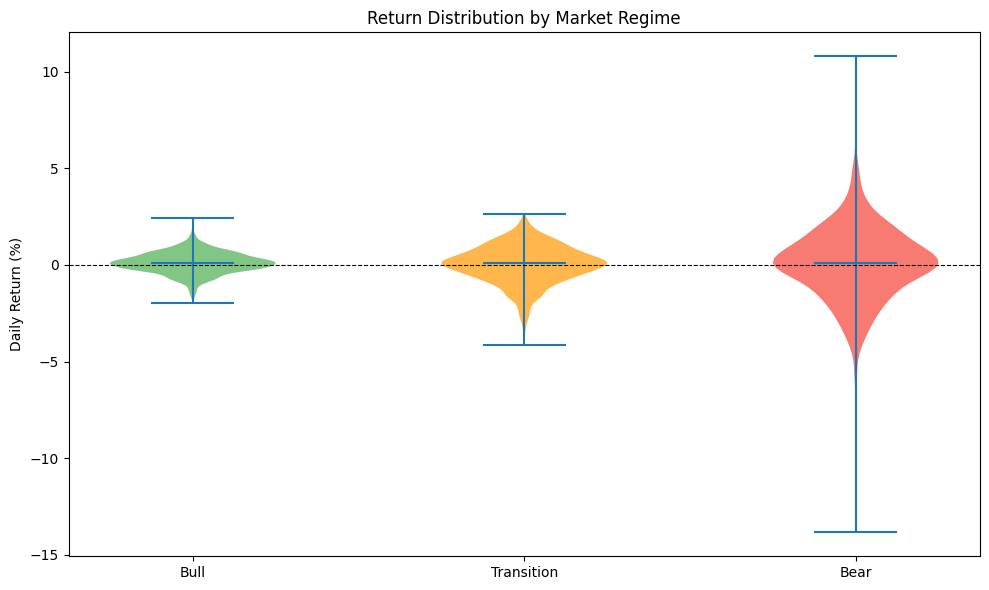

In [8]:
# ── Returns by Regime ─────────────────────────────────────────────────────────
# Validate: do regimes exhibit statistically different return distributions?

regime_stats = mkt_full.groupby('regime')['mkt_ret'].agg(['mean', 'std', 'count'])
regime_stats['annualized_ret']  = regime_stats['mean'] * 252 * 100
regime_stats['annualized_vol']  = regime_stats['std'] * np.sqrt(252) * 100
regime_stats['sharpe']          = regime_stats['annualized_ret'] / regime_stats['annualized_vol']
regime_stats.index = [REGIME_NAMES[int(i)] for i in regime_stats.index]
print('────── Returns by Regime ──────')
print(regime_stats.to_string())

# KS tests: are regime return distributions significantly different?
print('\n── Kolmogorov-Smirnov Tests ──')
bull_rets  = mkt_full[mkt_full['regime'] == 0]['mkt_ret'].dropna()
trans_rets = mkt_full[mkt_full['regime'] == 1]['mkt_ret'].dropna()
bear_rets  = mkt_full[mkt_full['regime'] == 2]['mkt_ret'].dropna()

for pair, r1, r2 in [
    ('Bull vs Transition', bull_rets, trans_rets),
    ('Bull vs Bear',       bull_rets, bear_rets),
    ('Transition vs Bear', trans_rets, bear_rets)
]:
    stat, pval = ks_2samp(r1, r2)
    print(f'  {pair:<22}: KS={stat:.4f}  p={pval:.6f}  {"✓ significant" if pval < 0.05 else "✗ not significant"}')

# Return distribution violin plots
fig, ax = plt.subplots(figsize=(10, 6))
regime_labels = [REGIME_NAMES[int(r)] for r in mkt_full['regime']]
rets_by_regime = {
    name: mkt_full[mkt_full['regime'] == i]['mkt_ret'].dropna() * 100
    for i, name in REGIME_NAMES.items()
}

parts = ax.violinplot(
    [rets_by_regime[n] for n in ['Bull', 'Transition', 'Bear']],
    positions=[0, 1, 2], showmedians=True, showextrema=True
)
for i, (pc, name) in enumerate(zip(parts['bodies'], ['Bull', 'Transition', 'Bear'])):
    pc.set_facecolor(REGIME_COLORS[name])
    pc.set_alpha(0.7)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Bull', 'Transition', 'Bear'])
ax.set_ylabel('Daily Return (%)')
ax.set_title('Return Distribution by Market Regime')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig(WD / 'regime_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Save Regime Models & Daily States

In [9]:
# Merge regime labels onto the panel for downstream notebooks
regime_export = mkt_full[['date', 'regime', 'p_bull', 'p_transition', 'p_bear',
                            'rolling_vol_21', 'rolling_vol_63', 'rolling_ret_21',
                            'vol_ratio', 'drawdown']].copy()
regime_export.to_parquet(WD / 'regime_states.parquet', index=False)

# Save HMM model
with open(WD / 'hmm_model.pkl', 'wb') as f:
    pickle.dump(best_hmm, f)

# Save HMM scaler
with open(WD / 'hmm_scaler.pkl', 'wb') as f:
    pickle.dump(hmm_scaler, f)

# Save GMM model
with open(WD / 'gmm_model.pkl', 'wb') as f:
    pickle.dump(gmm_final, f)

# State mapping
regime_meta = {
    'n_regimes':       N_REGIMES,
    'regime_names':    REGIME_NAMES,
    'hmm_features':    HMM_FEAT_COLS,
    'hmm_log_likelihood': float(best_score),
    'hmm_converged':   bool(best_hmm.monitor_.converged),
    'gmm_bic_optimal_n': int(best_n_bic),
    'hmm_gmm_agreement': float(agreement),
    'state_vol_mapping': {
        str(k): float(v) for k, v in sorted(state_vols.items(), key=lambda x: x[1])
    }
}
with open(WD / 'regime_meta.json', 'w') as f:
    json.dump(regime_meta, f, indent=2)

print('✓ Saved:')
print('  regime_states.parquet')
print('  hmm_model.pkl')
print('  hmm_scaler.pkl')
print('  gmm_model.pkl')
print('  regime_meta.json')
print(f'\nFinal regime distribution:')
rc = pd.Series(hmm_states).value_counts().sort_index()
for r, c in rc.items():
    print(f'  {REGIME_NAMES[r]:12s}: {c:5d} days ({c/len(hmm_states):.1%})')

✓ Saved:
  regime_states.parquet
  hmm_model.pkl
  hmm_scaler.pkl
  gmm_model.pkl
  regime_meta.json

Final regime distribution:
  Bull        :  1272 days (40.8%)
  Transition  :  1216 days (39.0%)
  Bear        :   629 days (20.2%)
